# Basic Properties

In [17]:
import rasterio

tif_path = "/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Images/Oil/00010.tif"

with rasterio.open(tif_path) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)

CRS: EPSG:4326
Bounds: BoundingBox(left=38.65563158301327, bottom=20.36103562992299, right=38.839606553200944, top=20.54501060011067)
Resolution: (8.983152841195208e-05, 8.983152841195208e-05)


# Cods of the center of the image

In [10]:
with rasterio.open(tif_path) as src:
    center_x = src.width // 2
    center_y = src.height // 2

    lon, lat = src.xy(center_y, center_x)

print("Image center location:")
print("Latitude:", lat)
print("Longitude:", lon)

Image center location:
Latitude: 20.452978199252623
Longitude: 38.74766398387131


# Convert imp information to dict

In [11]:
def extract_geoinfo(tif_path):
    with rasterio.open(tif_path) as src:
        center_x = src.width // 2
        center_y = src.height // 2

        lon, lat = src.xy(center_y, center_x)

        return {
            "crs": str(src.crs),
            "bounds": src.bounds,
            "center_lat": lat,
            "center_lon": lon
        }

info = extract_geoinfo(tif_path)
print(info)

{'crs': 'EPSG:4326', 'bounds': BoundingBox(left=38.65563158301327, bottom=20.36103562992299, right=38.839606553200944, top=20.54501060011067), 'center_lat': np.float64(20.452978199252623), 'center_lon': np.float64(38.74766398387131)}


# Test

In [28]:
def extract_oil_properties_from_mask(mask_tif):
    import rasterio
    import numpy as np
    import math
    from rasterio.transform import xy

    with rasterio.open(mask_tif) as src:
        mask = src.read(1)
        transform = src.transform
        pixel_width, pixel_height = src.res

    rows, cols = np.where(mask > 0)

    if len(rows) == 0:
        return None

    row_c = rows.mean()
    col_c = cols.mean()

    lon, lat = xy(transform, row_c, col_c)

    pixel_area = abs(pixel_width * pixel_height)
    area_m2 = len(rows) * pixel_area
    area_km2 = area_m2 / 1e6
    radius_m = math.sqrt(area_m2 / math.pi)

    return {
        "mask": mask,
        "latitude": lat,
        "longitude": lon,
        "area_m2": area_m2,
        "area_km2": area_km2,
        "radius_m": radius_m
    }

info = extract_oil_properties_from_mask("/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Mask/Oil/00001_segmentation.tif")

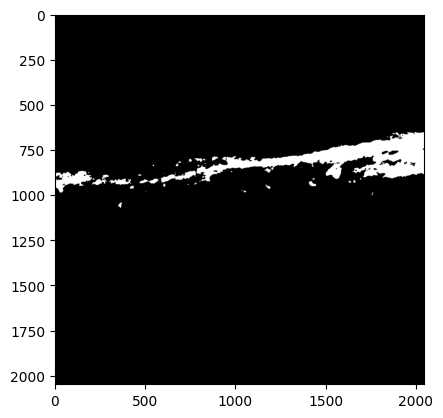

In [30]:
import matplotlib.pyplot as plt
plt.imshow(info['mask'], cmap="gray")

In [31]:
info

{'mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'latitude': np.float64(818.8485867924029),
 'longitude': np.float64(1404.9946822600725),
 'area_m2': 151004.0,
 'area_km2': 0.151004,
 'radius_m': 219.2397456058028}